In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric rdkit

!cp /content/drive/MyDrive/graph_vae_project.zip /content/

!unzip -q /content/graph_vae_project.zip -d /content/



Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 58.8 MB/s eta 0:00:00


In [2]:
import os

os.chdir('/content/src')

!python train_model_gcn1.py

!cp /content/src/model1_weights.pth /content/drive/MyDrive/


using device: cuda
loading data..
training on 15888 graphs...
Epoch 001/025 | Train Loss: 1.3632 (Recon: 1.3630, KL: 0.1493) | Val Loss: 0.9769
Epoch 005/025 | Train Loss: 0.9452 (Recon: 0.9439, KL: 1.3412) | Val Loss: 0.9354
Epoch 010/025 | Train Loss: 0.8840 (Recon: 0.8821, KL: 1.8907) | Val Loss: 0.8886
Epoch 015/025 | Train Loss: 0.8707 (Recon: 0.8688, KL: 1.9597) | Val Loss: 0.8767
Epoch 020/025 | Train Loss: 0.8543 (Recon: 0.8521, KL: 2.1552) | Val Loss: 0.8601
Epoch 025/025 | Train Loss: 0.8408 (Recon: 0.8387, KL: 2.1014) | Val Loss: 0.8490
Figure(1000x500)


Sampling 1000 random vectors from latent space...


  0%|          | 0/1000 [00:00<?, ?it/s][14:40:31] Explicit valence for atom # 15 Cl, 3, is greater than permitted
[14:40:31] Explicit valence for atom # 1 C, 5, is greater than permitted
[14:40:31] Explicit valence for atom # 6 Br, 2, is greater than permitted
[14:40:31] Explicit valence for atom # 11 Cl, 3, is greater than permitted
[14:40:31] Explicit valence for atom # 2 Br, 2, is greater than permitted
[14:40:31] Explicit valence for atom # 9 Br, 2, is greater than permitted
[14:40:31] Explicit valence for atom # 21 Br, 2, is greater than permitted
[14:40:31] Explicit valence for atom # 7 Br, 2, is greater than permitted
[14:40:31] Explicit valence for atom # 1 C, 5, is greater than permitted
[14:40:31] Explicit valence for atom # 2 O, 3, is greater than permitted
[14:40:31] Explicit valence for atom # 2 Br, 2, is greater than permitted
[14:40:31] Explicit valence for atom # 3 O, 3, is greater than permitted
[14:40:31] Explicit valence for atom # 1 C, 8, is greater than permitted



--- VUN Analysis ---
Validity (Poprawność):  72.80% (728/1000)
Uniqueness (Unikalność): 83.93% (611/728)
Unique smiles generated: {'C.CCCC.CCCCCCCCCCCCCC', 'C.C.C.CCCCCCCCCCCl', 'C.NCCCCCCCCCN', 'CC.CCC.CCCOCC', 'C.C.C.C.CCNCCC1CC1CCCCCCCN', 'C.CC.CCCCCCC.CCOC', 'C.CCO.NNCNCNCO', 'CCC.CCC.CCOC', 'C.CCCCCC.CCO', 'C.CCCC(CCC)COCC', 'CCCCCCCCCCl', 'CCCCCOCOC.CO.O', 'C.C.C.CC.CCC.CCCCCCCCC1C2CC12', 'C.C.C.CCCCCCCCCCCCCCCCCCC', 'C.CCCC.CCCCCCCCCC', 'CC.CC.CCCCCCCCCCC(C)C', 'C.CCCCC.CCCCCCCCCCCCCCC1CC1', 'CC1CCC(C)C2(C)CC2C1', 'C.CCCCCCCCCCCCl', 'NCNOCCCCCCOF', 'C.CCCCCCCCOCOCC', 'C.CC(O)CCCCCOCO', 'CC1CC2CC1CC(C)C2O', 'CCCCCCCCCCCCCCCCCCCC', 'C.CCC.CCCCCCCCCCCCC', 'C.C.C.CCCC.CCCCC1CC1', 'C.CCC.CCC.CCCCCCCCCCCCCCCCC', 'CCCC1CCCCCC1CCC', 'C.CCNCNCNCN', 'C.CCCCCCCC.CCNC', 'CC.CC.CCCCCCCCO', 'C.CC(CO)CC1C(C)C(C)C1(C)C(C)O.CO', 'C.CCCCCCCCCCCCCCCCCC', 'C.CCCCCCCCCCOCCNC', 'COC12CC3CC3(CC1CCO)C2', 'C.C.C.CC.CCCCCCCCCCCCCCCCCCCC', 'CCC.CCC.CCCC', 'CC.CC.CC.CCCCCCCCCC', 'CC.CCO.COC(C)O.O', 'C.C.C

100%|██████████| 16/16 [00:01<00:00, 12.18it/s]


Running t-SNE dimensionality reduction...
Latent space visualization saved as 'latent_space_analysis.png'


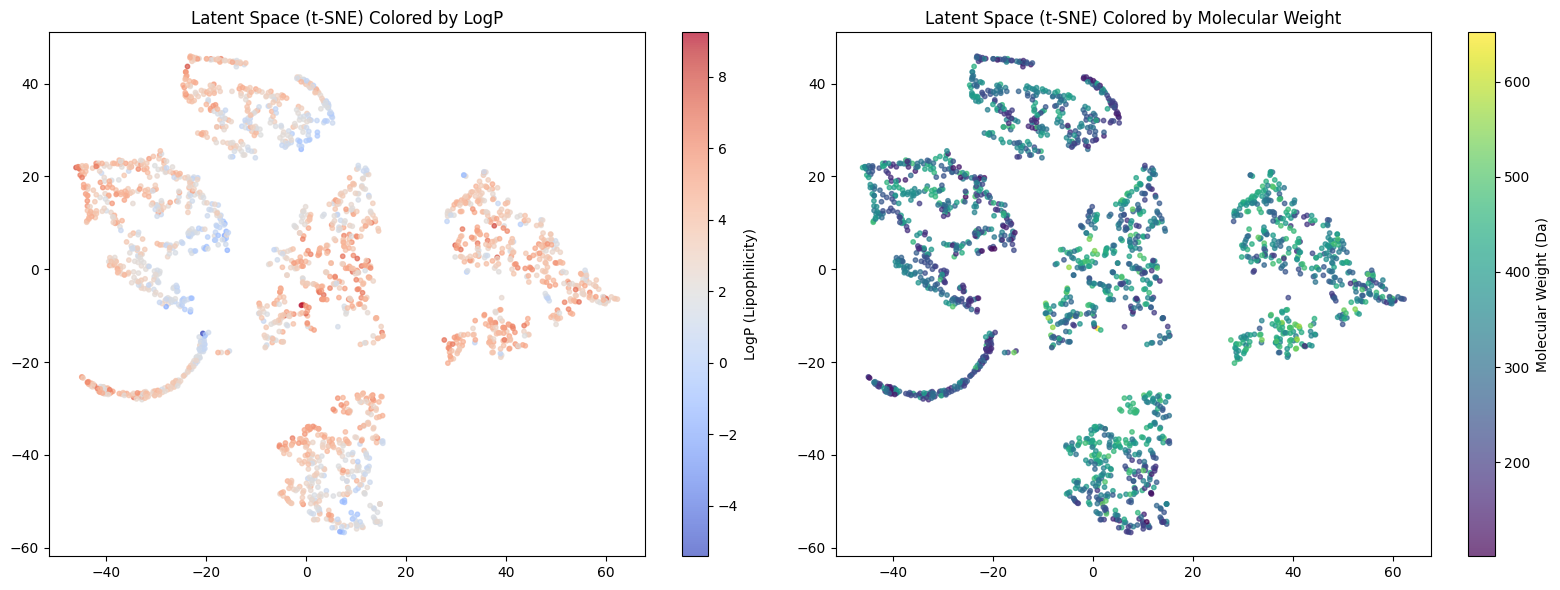

In [6]:
import torch
import pandas as pd
from torch_geometric.loader import DataLoader
import os

os.chdir('/content/src')
from train_model_gcn1 import GraphVAE
from evaluate import GraphVAEEvaluator

SUPPORTED_ATOMS = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]
NUM_ATOM_TYPES = len(SUPPORTED_ATOMS)
NODE_FEATURES = NUM_ATOM_TYPES
HIDDEN_DIM = 64
LATENT_DIM = 128
MAX_NODES = 37

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphVAE(NODE_FEATURES, HIDDEN_DIM, LATENT_DIM, MAX_NODES, NUM_ATOM_TYPES)
model.load_state_dict(torch.load('model1_weights.pth', map_location=device, weights_only=True))
model = model.to(device)
model.eval()

csv_path = '/content/drive/MyDrive/smiles_selfies_full.csv'
df = pd.read_csv(csv_path)
train_smiles_list = df['smiles'].tolist()

test_dataset = torch.load('../data/subset/test.pt', weights_only=False)
test_dataset = [g for g in test_dataset if g.num_nodes <= MAX_NODES]
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

evaluator = GraphVAEEvaluator(
    model=model,
    device=device,
    max_nodes=MAX_NODES,
    train_smiles_list=train_smiles_list
)

validity, uniqueness, novelty = evaluator.evaluate_vun(num_samples=1000)

evaluator.visualize_latent_space(test_loader)